# LSTM for Stock Price Prediction using Yahoo Financial Historical Dataset


In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [2]:
# Download stock data
data = yf.download("AAPL", start="2015-01-01", end="2024-01-01")
data = data[['Close']]

/tmp/ipykernel_5239/3716854650.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2015-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


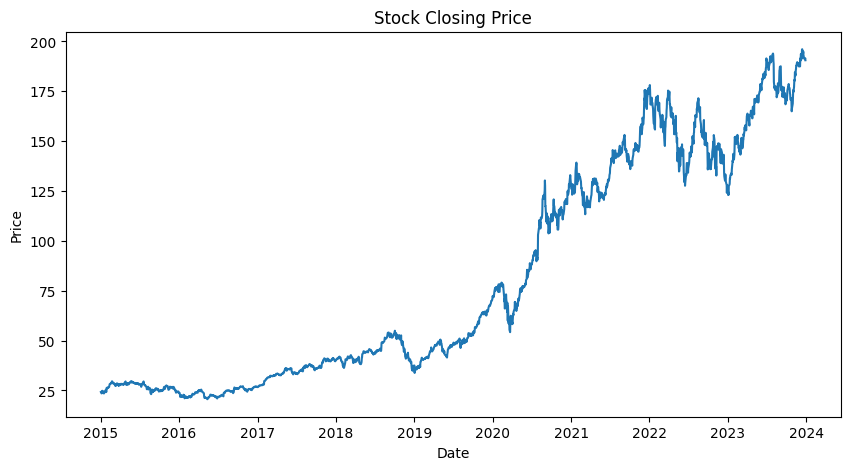

In [3]:
# Plot original data
plt.figure(figsize=(10,5))
plt.plot(data['Close'])
plt.title("Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [4]:
# Normalize data
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

In [5]:
# Create training dataset
x_train, y_train = [], []
for i in range(60, len(scaled_data)):
    x_train.append(scaled_data[i-60:i, 0])
    y_train.append(scaled_data[i, 0])

x_train = np.array(x_train)
y_train = np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

In [6]:
# Build LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(x_train.shape[1],1)))
model.add(Dropout(0.2))
model.add(LSTM(50, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(50))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
# Train model
model.fit(x_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - loss: 0.0167
Epoch 2/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0030
Epoch 3/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0027
Epoch 4/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 0.0029
Epoch 5/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0026
Epoch 6/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0024
Epoch 7/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0024
Epoch 8/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 0.0028
Epoch 9/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 0.0022
Epoch 10/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - loss: 0.0022
Epoch 11/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0023
Epoch 12/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.0021
Epoch 13/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - loss: 0.0021
Epoch 14/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.0019
Epoch 15/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0018
Epoc

In [8]:
# Load test data
test_data = yf.download("AAPL", start="2024-01-01", end="2025-01-01")
actual_prices = test_data[['Close']]

/tmp/ipykernel_5239/885850685.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  test_data = yf.download("AAPL", start="2024-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


In [9]:
# Prepare inputs
total_dataset = pd.concat((data['Close'], test_data['Close']), axis=0)
model_inputs = total_dataset[len(total_dataset) - len(test_data) - 60:].values
model_inputs = model_inputs.reshape(-1,1)
model_inputs = scaler.transform(model_inputs)

In [11]:
# Create test sequences
x_test = []
for i in range(60, len(model_inputs)):
    x_test.append(model_inputs[i-60:i,0])
x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

In [12]:
# Predict
predicted_prices = model.predict(x_test)
predicted_prices = scaler.inverse_transform(predicted_prices)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step


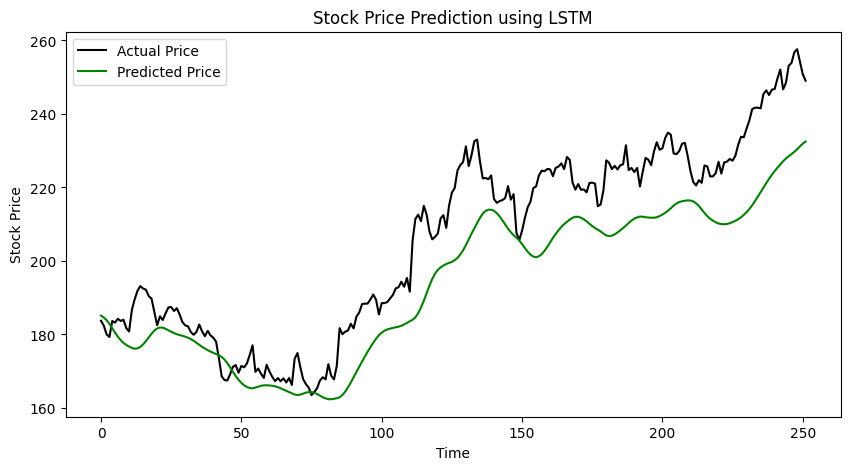

In [13]:
# Plot results
plt.figure(figsize=(10,5))
plt.plot(actual_prices.values, color='black', label='Actual Price')
plt.plot(predicted_prices, color='green', label='Predicted Price')
plt.title("Stock Price Prediction using LSTM")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()